<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación. 
#### La prueba se realiza utilizando el conjunto de datos 0. 
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Primero
#id_train = "270043001951343334363036"
#id_test = "46004e000251353337353037"

In [2]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037" 

In [3]:
# Tercero
id_train = "200034001951343334363036"
id_test = "46005a000351353337353037"

In [4]:
# Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037" 

In [5]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
from IPython.display import HTML
#import imgkit

2024-11-27 20:56:13.536670: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Variables a definir

In [6]:
seq_length = 120
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [7]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [8]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

####  La función create_sequences toma dos conjuntos de datos, X e y, y un parámetro seq_length que define la longitud de cada secuencia de entrada que se va a crear. Su objetivo es estructurar los datos en secuencias de longitud fija, lo cual es muy útil en modelos que procesan secuencias, como los modelos de series temporales o redes neuronales recurrentes (RNNs).

#### El bucle for recorre los datos hasta len(X) - seq_length para garantizar que se pueden crear secuencias completas de longitud seq_length.
#### En cada iteración:
#### X[i:(i+seq_length)]: Extrae una secuencia de longitud seq_length de X, que va desde el índice i hasta i+seq_length (sin incluir i+seq_length). Esta secuencia se agrega a xs.
#### y[i+seq_length]: Obtiene el valor objetivo en el índice i + seq_length y lo agrega a ys. Esto representa el valor que queremos predecir después de observar la secuencia anterior.

In [9]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

#### La clase PlotLearning es una callback personalizada de Keras que se usa para graficar las métricas de entrenamiento y validación durante el proceso de entrenamiento de un modelo. Hereda de Callback, que es una clase de Keras que permite ejecutar código específico en diferentes momentos del entrenamiento (como al inicio o al final de cada época).

#### - Metodo **on_train_begin**: Este método se ejecuta al inicio del entrenamiento. Inicializa listas vacías para almacenar las métricas de:
- Error absoluto medio (MAE) en el conjunto de entrenamiento (train_mean_absolute_error).
- Pérdida en el conjunto de entrenamiento (train_loss).
- Error absoluto medio (MAE) en el conjunto de validación (val_mean_absolute_error).
- Pérdida en el conjunto de validación (val_loss).

#### método **on_epoch_end**: Este método se ejecuta al final de cada época. Extrae las métricas del argumento logs, que contiene el valor de diferentes métricas calculadas al final de la época, y las agrega a las listas correspondientes:
- mean_absolute_error y loss: Son métricas del conjunto de entrenamiento.
- val_mean_absolute_error y val_loss: Son métricas del conjunto de validación.

#### clear_output(wait=True): Borra el contenido anterior para que el gráfico de métricas se actualice en cada época.
#### plt.figure(figsize=(12, 5)): Define el tamaño de la figura para que sea más amplia y fácil de leer.

#### plt.tight_layout(): Ajusta el espaciado para que las gráficas se acomoden bien en la figura.

In [10]:
class PlotLearning(Callback):
    """
    Callback to plot the metrics during training.
    """
    def on_train_begin(self, logs={}):
        self.train_mean_absolute_error = []
        self.train_loss = []
        self.val_mean_absolute_error = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs={}):
        self.train_mean_absolute_error.append(logs.get('mean_absolute_error'))
        self.train_loss.append(logs.get('loss'))
        self.val_mean_absolute_error.append(logs.get('val_mean_absolute_error'))
        self.val_loss.append(logs.get('val_loss'))

        clear_output(wait=True)
        plt.figure(figsize=(12, 5))

        # Graficar precisión MAE
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), self.train_mean_absolute_error, 'o--', label='Training MAE')
        plt.plot(range(1, epoch + 2), self.val_mean_absolute_error, 'o--', label='Validation MAE')
        plt.xlabel('# epochs')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid()

        # Graficar pérdida MSE
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), self.train_loss, 'o--', label='Training MSE')
        plt.plot(range(1, epoch + 2), self.val_loss, 'o--', label='Validation MSE')
        plt.xlabel('# epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

### Parámetros de entrada:

#### test: DataFrame que contiene los datos de prueba con columnas como "Rain meter", "Soil moisture", "Battery" y "date".
#### seq_length: Longitud de la secuencia usada para formar las entradas al modelo.
#### forecast_steps: Número total de pasos a predecir.
#### future_steps: Número de pasos para actualizar la predicción con los datos históricos.
#### model: Modelo predictivo usado para el pronóstico.
#### scaler_x y scaler_y: Escaladores para normalizar las características y el objetivo, respectivamente.

### Inicialización de los datos históricos y del pronóstico:

#### historical_data: Primeros seq_length+1 datos para usar como secuencia inicial.
#### forecast_data: Conjunto de datos sobre el que se va a realizar el pronóstico.
#### weather_forecast: DataFrame de forecast_data sin la columna "Battery", que será reemplazada por predicciones.

### Bucle de pronóstico:

#### El bucle recorre forecast_steps, y en cada iteración:
- Normaliza los datos históricos usando normalise_data.
- Crea secuencias con create_sequences para proporcionar datos secuenciales al modelo.
- Realiza la predicción del siguiente nivel de batería usando el modelo, luego inversa la normalización de la predicción para obtener el valor real de batería.
- Agrega la predicción al pronóstico en weather_forecast, reemplazando valores NaN con la predicción.
- Actualiza los datos históricos concatenando los datos más recientes del pronóstico en updated_historical_data.

In [11]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """
    
    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos 

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])
        
        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv
        
        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [12]:
def compare_model_performance(test, seq_length, future_steps, models, scaler_x, scaler_y):
    """
    This function is used to compare the performance of multiple models in terms of their ability to predict battery
    consumption based on historical data. It returns a list of dictionaries, each containing the minimum, maximum, mean,
    and standard deviation of the Mean Absolute Error (MAE) for each model.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    future_steps (int): Number of steps to shift for updating historical data.
    models (dict): Dictionary of models used for prediction, with model names as keys and models as values.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    list: A list of dictionaries. Each dictionary contains the model name as the key and the 'min', 'max', 'mean' and 'std' of
    the Mean Absolute Error (MAE) for the corresponding model as values.
    """

    num_intervals = len(test) // seq_length + 1 # 3791 / 121 = 31
    metrics_list = {model_name: {'mae': [], 'fecha': [], 'stats': {}} for model_name, model in models}

    forecast_data_all = pd.DataFrame()
    
    # Para cada modelo hacemos el proceso
    for model_name, model in models:
        for i in range(num_intervals):
            # Recorremos todas las posibles secuencias de 120 datos, hasta el fin del dataset
            historical_data = test[i*seq_length:(i+1)*seq_length+1]
            # Último datos de cada secuencia de 120, sobre el cual realizamos la predicción
            forecast_data = test[(i+1)*seq_length:((i+1)*seq_length)+future_steps]
            # Quitamos batería
            weather_forecast = forecast_data.drop(columns=['battery'])
            # Rellenamos batería con Nan
            weather_forecast['battery'] = np.nan
            updated_historical_data = historical_data
            
            # Hacemos las predicciones igual que antes
            for steps in range(future_steps):
                if steps < len(weather_forecast):

                    # normalise historical_data
                    X_hist, y_hist = normalise_data(scaler_x,
                                                    updated_historical_data.drop(columns=['fecha']),
                                                    scaler_y,
                                                    updated_historical_data['battery'])
                    # create sequences out of historical_data
                    X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

                    # predict next battery level
                    next_battery_pred = model.predict(X_hist_seq, verbose = 0)

                    # inverse normalisation of predicted battery level
                    next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

                    # Add predicted value to weather forecast
                    weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

                    # Update the historical data with the forecasted
                    updated_historical_data = pd.concat([updated_historical_data[1:], weather_forecast.iloc[[steps]]], ignore_index=True)


            clear_output(wait=True)
            print(f'{i}/{num_intervals} intervals ===>  {steps}/{future_steps} steps')

            if not forecast_data.empty and not weather_forecast['battery'].isnull().all():
                 # Save metrics to list
                metrics_list[model_name]['mae'].append(mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))
                metrics_list[model_name]['fecha'].append(pd.to_datetime(updated_historical_data['fecha'])[0])


    plt.figure(figsize=(20, 6))

    for model_name, metrics in metrics_list.items():
        plt.plot(metrics['fecha'], metrics['mae'], label=model_name)
        metrics['stats'] = {'min': np.min(metrics['mae']), 'max': np.max(metrics['mae']), 'mean': np.mean(metrics['mae']), 'std': np.std(metrics['mae'])}

    plt.title('MAE over Time intervals')
    plt.xlabel('Interval')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid()
    plt.show()

    return [{model_name: metrics['stats']} for model_name, metrics in metrics_list.items()]

In [13]:
def df_to_image(df, filename):
    """
    Convert a pandas DataFrame into a styled PNG image, maintaining the order of the DataFrame as it is passed.

    Args:
      df (pandas.DataFrame): The DataFrame to convert.
      filename (str): The base name of the files to create. The HTML file will be named
          '{filename}.html' and the image file will be named '{filename}.png'.
    """
    
    sampled_df = df  # Si hay 10 o menos filas, mostrar todo el DataFrame

    # Redondear y estilizar el DataFrame
    styled = sampled_df.style.format(precision=2).set_table_styles(
        [dict(selector="tr:nth-of-type(odd) td", props=[("background", "#eee")]),
         dict(selector="tr:nth-of-type(even) td", props=[("background", "white")])])

    # Guardar como HTML y luego convertir a PNG
    html_file = f'{filename}.html'
    styled.to_html(html_file)
    imgkit.from_file(html_file, f'{filename}.png')
    os.remove(html_file)


### Cargamos el conjunto de datos según lo definido al principio

In [14]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [15]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [16]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [17]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [18]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  15714
Number of testing sets:  3834


In [19]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15714 entries, 2018-04-02 00:00:00 to 2018-09-14 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    15714 non-null  float64
 1   pressure       15714 non-null  float64
 2   battery        15714 non-null  float64
 3   air_humidity   15714 non-null  float64
 4   soil_humidity  15714 non-null  float64
 5   wind_speed     15714 non-null  float64
 6   irradiancia    15714 non-null  float64
 7   minutos_dia    15714 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1.1 MB


In [20]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3834 entries, 2018-08-24 00:00:00 to 2018-10-03 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    3834 non-null   float64
 1   pressure       3834 non-null   float64
 2   battery        3834 non-null   float64
 3   air_humidity   3834 non-null   float64
 4   soil_humidity  3834 non-null   float64
 5   wind_speed     3834 non-null   float64
 6   irradiancia    3834 non-null   float64
 7   minutos_dia    3834 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 269.6 KB


In [21]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-04-02 00:00:00,13.56,1004.63,76.02,57.87,20.03,0.00,0.0,765
2018-04-02 00:15:00,13.33,1004.68,75.37,58.06,19.42,2.08,0.0,765
2018-04-02 00:45:00,13.48,1004.14,74.38,57.51,19.32,2.08,0.0,765
2018-04-02 01:00:00,13.10,1004.13,74.05,58.22,19.13,0.00,0.0,765
2018-04-02 01:15:00,12.84,1003.96,73.56,59.37,19.17,0.00,0.0,765


In [22]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-24 00:00:00,22.46,986.00,70.94,60.43,69.66,2.41,0.0,807
2018-08-24 00:15:00,22.22,986.00,70.61,59.96,69.33,2.41,0.0,807
2018-08-24 00:30:00,21.84,986.14,70.28,60.01,69.33,0.00,0.0,807
2018-08-24 00:45:00,21.69,986.01,70.12,60.60,69.37,0.00,0.0,807
2018-08-24 01:00:00,21.29,986.32,69.62,60.81,69.58,0.00,0.0,807


#### Alineación de puntos de datos según marcas de tiempo

In [23]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [24]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-06-23 01:00:00,26.1075,1006.6500,70.4450,62.2025,14.5375,0.52,0.00,904.0
2018-06-30 16:00:00,36.7825,998.6925,82.2100,40.4425,14.9300,7.27,495.95,902.0
2018-05-22 09:00:00,28.8250,1002.7650,50.2000,47.3875,27.7250,2.08,672.70,879.0
2018-05-29 06:00:00,19.7125,1004.2350,52.2800,79.3575,15.0075,0.52,85.76,889.0
2018-07-20 19:00:00,36.1150,1000.2075,82.6225,49.6150,15.0125,3.12,7.16,880.0


In [25]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-09-10 22:00:00,19.9625,994.0725,65.8550,78.7950,58.4475,0.6025,0.00,764.0
2018-09-02 17:00:00,32.8150,984.3725,79.6075,59.0350,71.4450,4.2200,101.26,785.0
2018-09-10 10:00:00,24.3575,992.9425,41.7300,77.7200,16.1600,1.5075,559.48,764.0
2018-08-26 16:00:00,37.3900,984.4300,79.4400,40.9175,70.0375,3.0125,333.41,802.0
2018-09-30 01:00:00,15.3825,987.5175,10.1275,71.2300,60.9175,0.0000,0.00,712.0


In [26]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [27]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,19.5900,1.386667,0.0,765.0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,19.2450,0.000000,0.0,765.0
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,19.8775,1.040000,0.0,765.0
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,20.6975,0.520000,0.0,765.0
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,19.5800,1.040000,0.0,765.0


In [28]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0


In [29]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [30]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,19.5900,1.386667,0.0,765.0,0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,19.2450,0.000000,0.0,765.0,1
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,19.8775,1.040000,0.0,765.0,2
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,20.6975,0.520000,0.0,765.0,3
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,19.5800,1.040000,0.0,765.0,4


In [31]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0,4


In [32]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [33]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,1.386667,0.0,765.0,0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,0.000000,0.0,765.0,1
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,1.040000,0.0,765.0,2
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,0.520000,0.0,765.0,3
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,1.040000,0.0,765.0,4


In [34]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,1.8075,0.0,807.0,4


In [35]:
#X_trains = []
#y_trains = []
#X_vals = []
#y_vals = []

In [36]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [37]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [38]:
X_train.head(12)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,13.456667,1004.483333,75.256667,57.813333,1.386667,0.00,765.0,0
1,12.680000,1003.887500,73.480000,58.852500,0.000000,0.00,765.0,1
2,11.747500,1003.202500,72.250000,58.555000,1.040000,0.00,765.0,2
3,11.962500,1002.612500,71.182500,61.107500,0.520000,0.00,765.0,3
4,11.855000,1002.335000,70.200000,64.217500,1.040000,0.00,765.0,4
5,11.882500,1001.755000,69.212500,62.810000,1.040000,0.00,765.0,5
6,10.905000,1001.145000,67.882500,63.180000,1.560000,42.60,765.0,6
7,10.732500,1000.985000,66.397500,62.742500,1.040000,155.38,765.0,7
8,12.112500,1000.930000,64.697500,60.677500,1.040000,284.34,765.0,8
9,14.037500,1000.992500,64.012500,52.920000,1.560000,406.05,765.0,9


In [39]:
#df_img = X_train.head(12)
#df_to_image(df_img, "df_24horas")

In [40]:
X_val.head(24)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
3168,27.0700,1009.3700,69.0500,79.1900,0.5200,0.00,836.0,0
3169,26.7425,1008.9250,66.9400,78.9500,0.5200,0.00,836.0,1
3170,26.2950,1008.1950,64.9175,78.7000,1.5600,0.00,836.0,2
3171,25.9500,1007.7250,62.6750,78.4600,0.0000,0.00,836.0,3
3172,25.5425,1007.2850,59.3175,78.2200,2.0800,0.00,836.0,4
3173,25.5475,1007.0350,54.6325,77.9800,2.6000,26.97,836.0,5
3174,25.3250,1006.8300,50.3925,77.7400,1.5600,168.79,836.0,6
3175,26.0950,1006.8525,46.3975,77.4925,1.5600,358.90,836.0,7
3176,30.8450,1006.8125,43.2300,71.3125,2.0800,547.40,836.0,8
3177,33.0725,1006.8025,42.5125,65.2300,3.1175,700.77,836.0,9


In [41]:
y_train.head(3)

0    75.256667
1    73.480000
2    72.250000
Name: battery, dtype: float64

In [42]:
y_val.head(3)

3168    69.0500
3169    66.9400
3170    64.9175
Name: battery, dtype: float64

In [43]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [44]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.122983,0.692589,0.770880,0.630312,0.133462,0.0,0.0,0.000000
1,0.101800,0.675299,0.748231,0.647668,0.000000,0.0,0.0,0.043478
2,0.076367,0.655423,0.732551,0.642699,0.100096,0.0,0.0,0.086957
3,0.082231,0.638303,0.718943,0.685331,0.050048,0.0,0.0,0.130435
4,0.079299,0.630250,0.706419,0.737275,0.100096,0.0,0.0,0.173913


In [45]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría 
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [46]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [47]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [48]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.360830,0.228213,0.815646,0.66045,0.136209,0.0,1.0,0.000000
1,0.338225,0.237288,0.800686,0.68711,0.136209,0.0,1.0,0.043478
2,0.430668,0.224476,0.783762,0.69034,0.477016,0.0,1.0,0.086957


In [49]:
y_test.head(3)

,0
0,0.815646
1,0.800686
2,0.783762


In [50]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [51]:
type(X_test_seq)

numpy.ndarray

In [52]:
y_test_seq[0]

array([0.81854981])

In [53]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (3048, 120, 8)
Dimensiones de los datos de validación: (673, 120, 8)
Dimensiones de los datos de testeo: (841, 120, 8)
Dimensiones de las etiquetas de entrenamiento: (3048, 1)
Dimensiones de las etiquetas de validación: (673, 1)
Dimensiones de las etiquetas de testeo: (841, 1)


In [54]:
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
n_steps, n_features

(120, 8)

### Modelo LSTM

In [55]:
# Define model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="relu", input_shape=(n_steps, n_features)))
lstm_model.add(Dense(1, activation="sigmoid"))
lstm_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_model.summary()

2024-11-21 22:05:19.715007: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-21 22:05:19.740424: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-21 22:05:19.740657: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-21 22:05:19.740990: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuil

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                11800     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 11,851
Trainable params: 11,851
Non-trainable params: 0
_________________________________________________________________


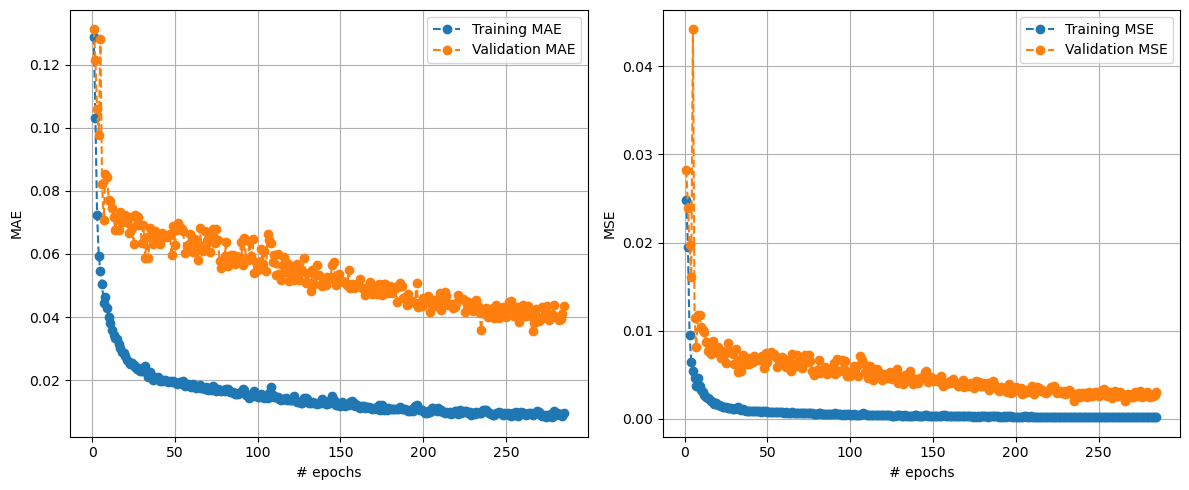

43/43 [==============================] - 6s 135ms/step - loss: 1.9691e-04 - mean_absolute_error: 0.0097 - val_loss: 0.0031 - val_mean_absolute_error: 0.0436


In [56]:
lstm_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

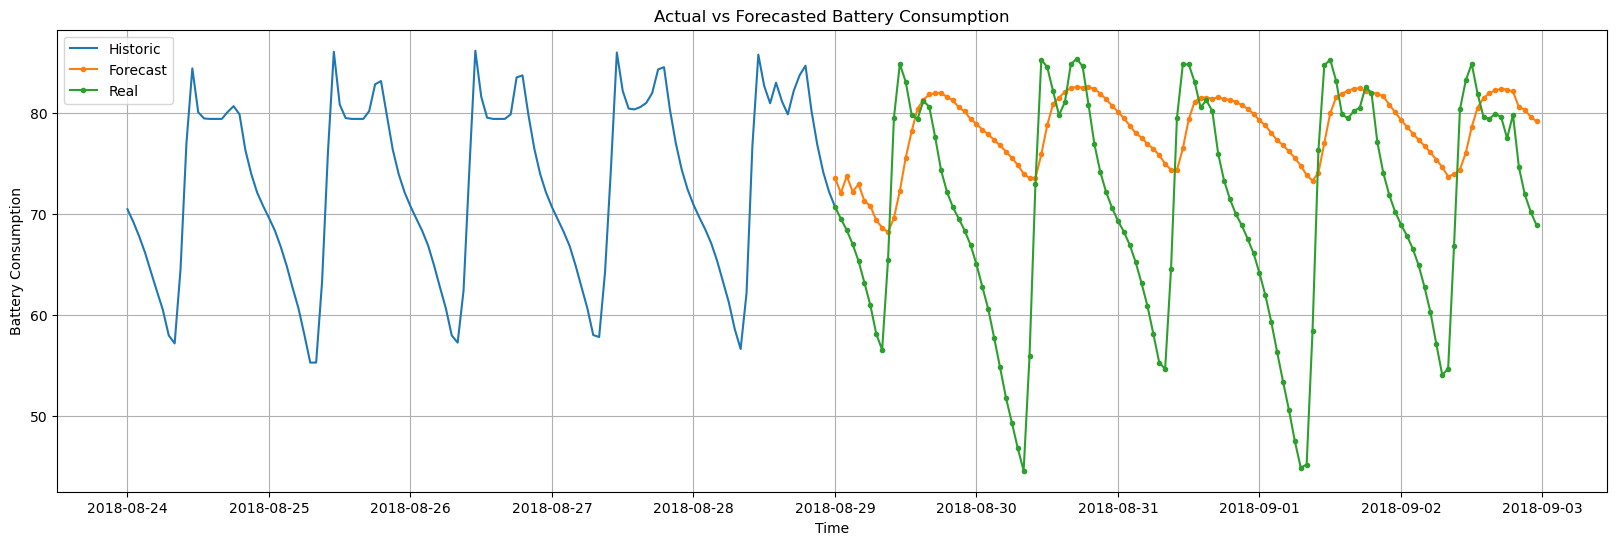

RMSE:  12.357637928518947
MSE:   152.71121517237006
MAE:   9.823777863396538


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [57]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, 
                             forecast_steps=seq_length, future_steps=future_steps, model=lstm_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble LSTM

In [58]:
# Define model
lstm_double_model = Sequential()
lstm_double_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_double_model.add(LSTM(50))
lstm_double_model.add(Dense(1, activation="sigmoid"))
lstm_double_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_double_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 120, 50)           11800     
                                                                 
 lstm_2 (LSTM)               (None, 50)                20200     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 32,051
Trainable params: 32,051
Non-trainable params: 0
_________________________________________________________________


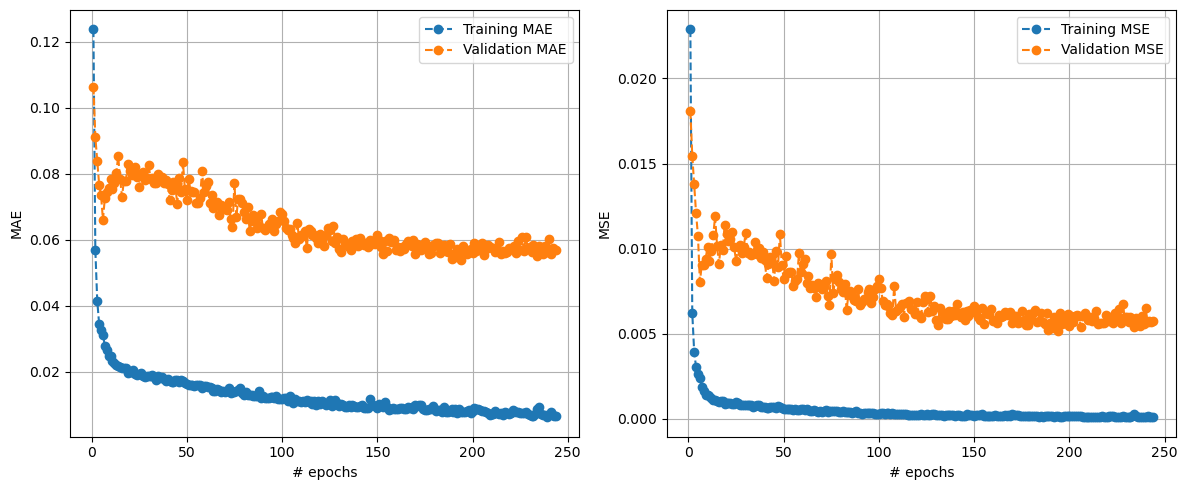

43/43 [==============================] - 1s 25ms/step - loss: 8.8457e-05 - mean_absolute_error: 0.0065 - val_loss: 0.0058 - val_mean_absolute_error: 0.0568


In [59]:
lstm_double_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

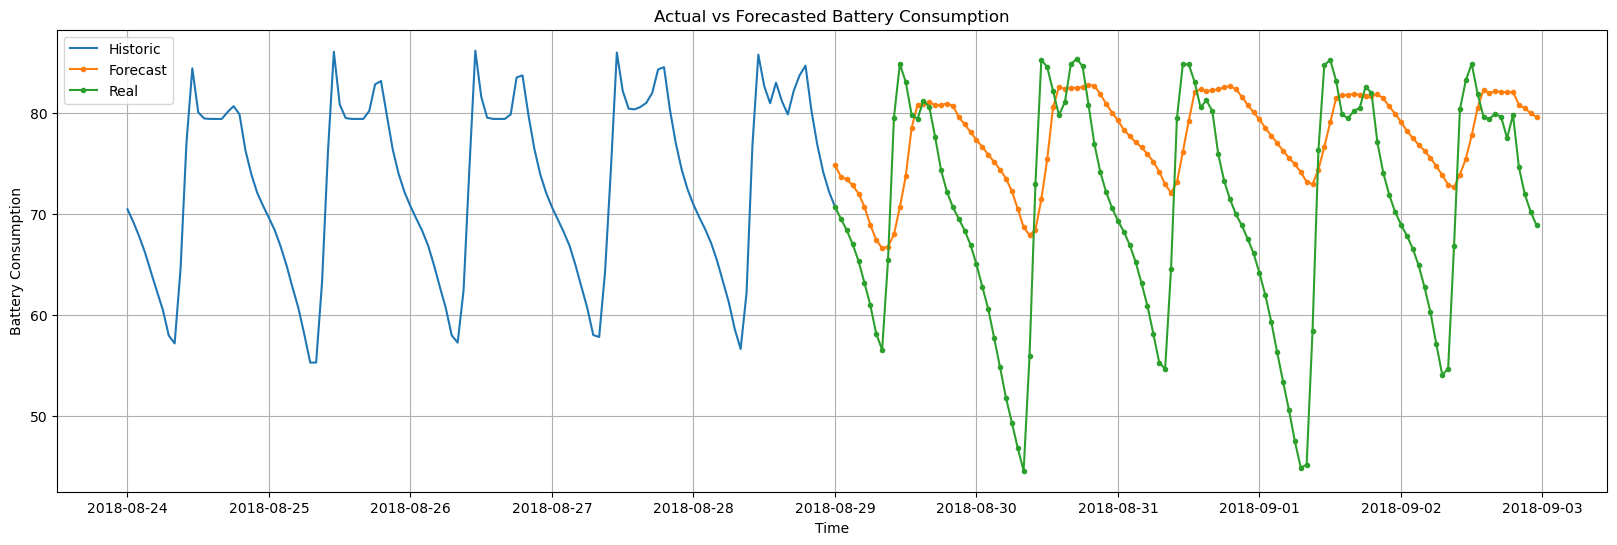

RMSE:  11.723394030031443
MSE:   137.4379675833769
MAE:   9.506157560560439


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [60]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=lstm_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo LSTM libro Jason

In [61]:
n_nodes = 50
# define model
model = Sequential()
model.add(LSTM(n_nodes, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dense(n_nodes, activation='relu'))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 50)                11800     
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 14,401
Trainable params: 14,401
Non-trainable params: 0
_________________________________________________________________


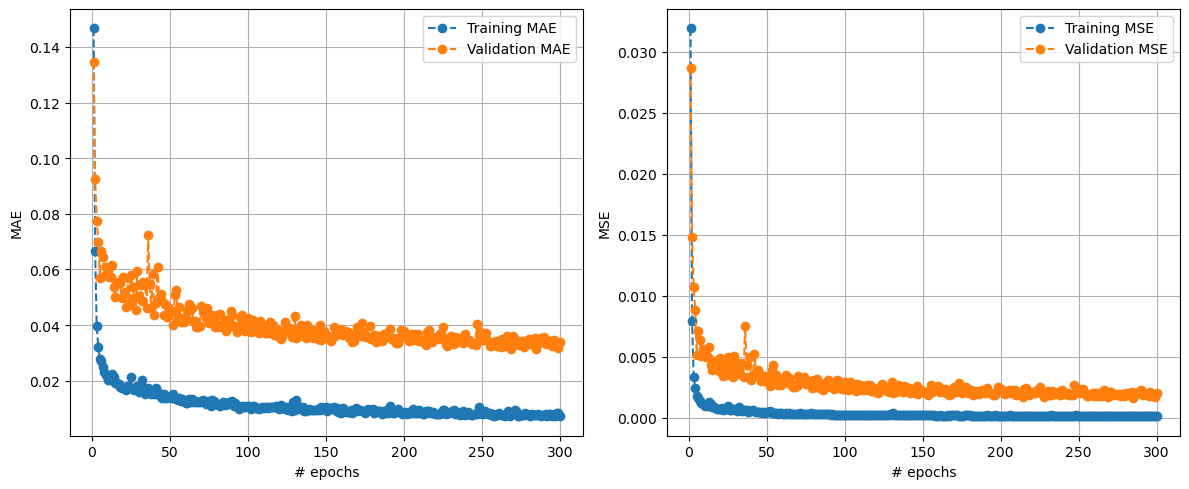

43/43 [==============================] - 6s 133ms/step - loss: 1.3168e-04 - mean_absolute_error: 0.0074 - val_loss: 0.0020 - val_mean_absolute_error: 0.0337


In [62]:
model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

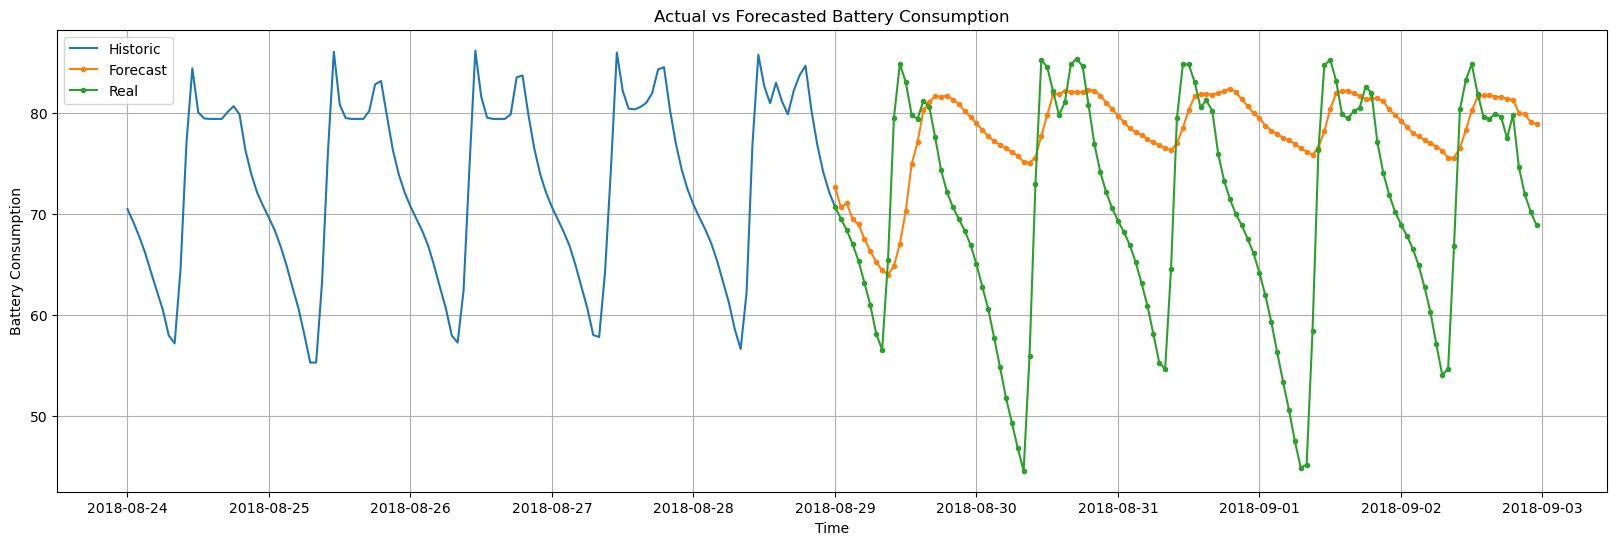

RMSE:  12.714111638008948
MSE:   161.64863474375457
MAE:   9.821133334689671


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [63]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo Sofisticado

In [55]:
from keras.layers import Dropout

# Crear el modelo
model = Sequential()
# Capa LSTM 1 (con 50 unidades)
model.add(LSTM(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
model.add(Dropout(0.2))
# Capa LSTM 2 (con 50 unidades)
model.add(LSTM(50))
# Dropout para regularización
model.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
model.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
model.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
model.summary()

2024-11-27 20:56:36.670068: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-27 20:56:36.965304: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-27 20:56:36.965843: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-11-27 20:56:36.967685: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuil

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 120, 50)           11800     
                                                                 
 dropout (Dropout)           (None, 120, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 64)                3264      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 3

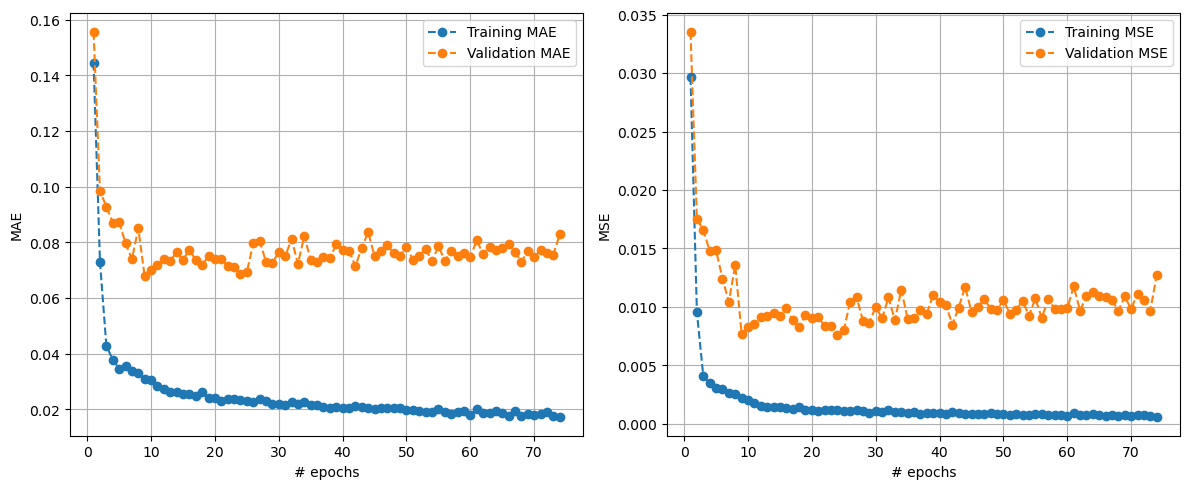

43/43 [==============================] - 1s 28ms/step - loss: 6.1973e-04 - mean_absolute_error: 0.0174 - val_loss: 0.0127 - val_mean_absolute_error: 0.0829


In [56]:
model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

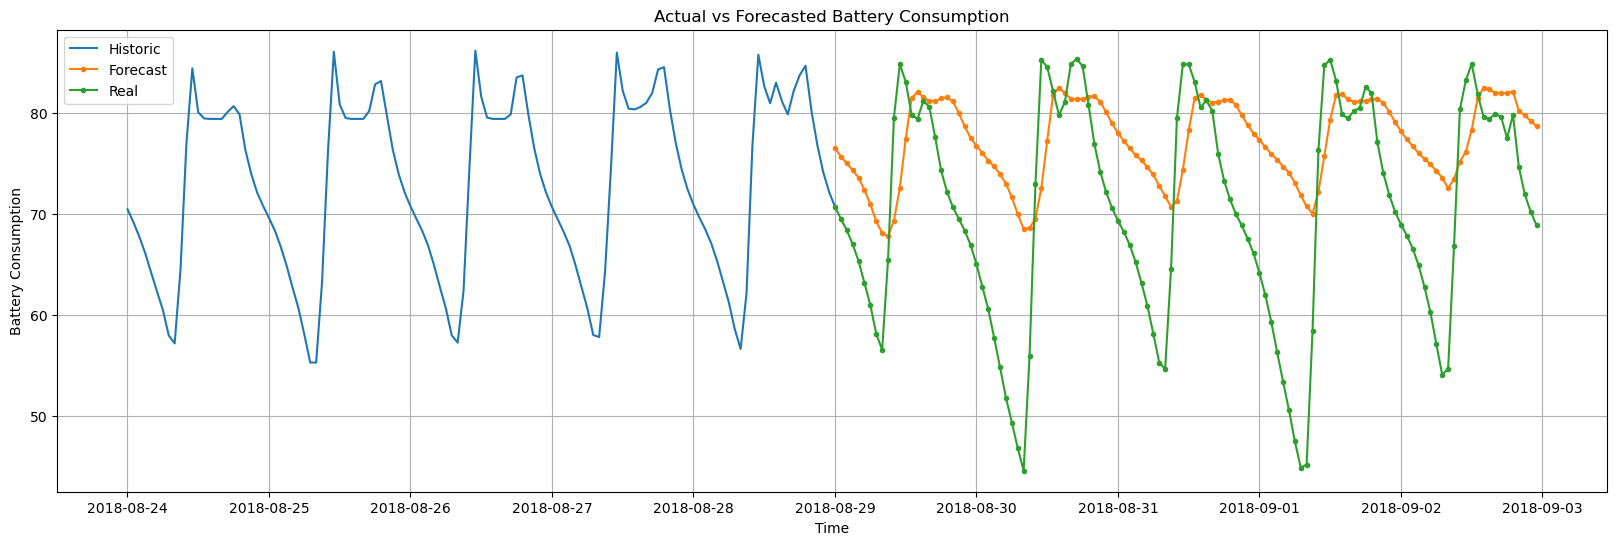

RMSE:  11.107128917704298
MSE:   123.36831279450305
MAE:   9.077322139316134


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [57]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU

In [67]:
# Define model
gru_model = Sequential()
gru_model.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_model.add(Dense(1, activation='sigmoid'))
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 50)                9000      
                                                                 
 dense_7 (Dense)             (None, 1)                 51        
                                                                 
Total params: 9,051
Trainable params: 9,051
Non-trainable params: 0
_________________________________________________________________


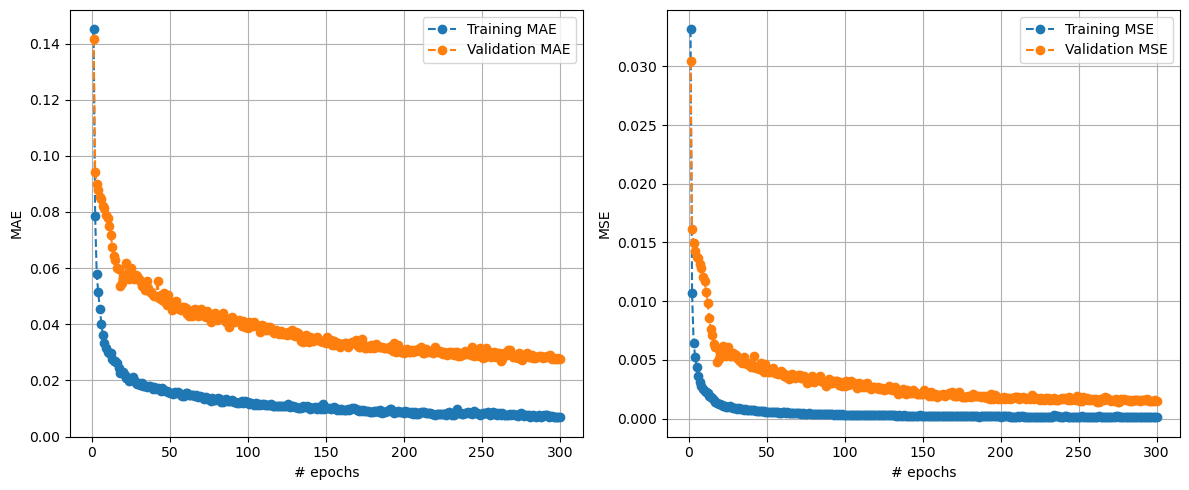

43/43 [==============================] - 1s 19ms/step - loss: 1.0861e-04 - mean_absolute_error: 0.0071 - val_loss: 0.0015 - val_mean_absolute_error: 0.0276


In [68]:
gru_model.fit(X_train_seq,
              y_train_seq,
              epochs=300,
              batch_size=72,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[
              PlotLearning(),
              EarlyStopping(monitor='val_loss', patience=50)])

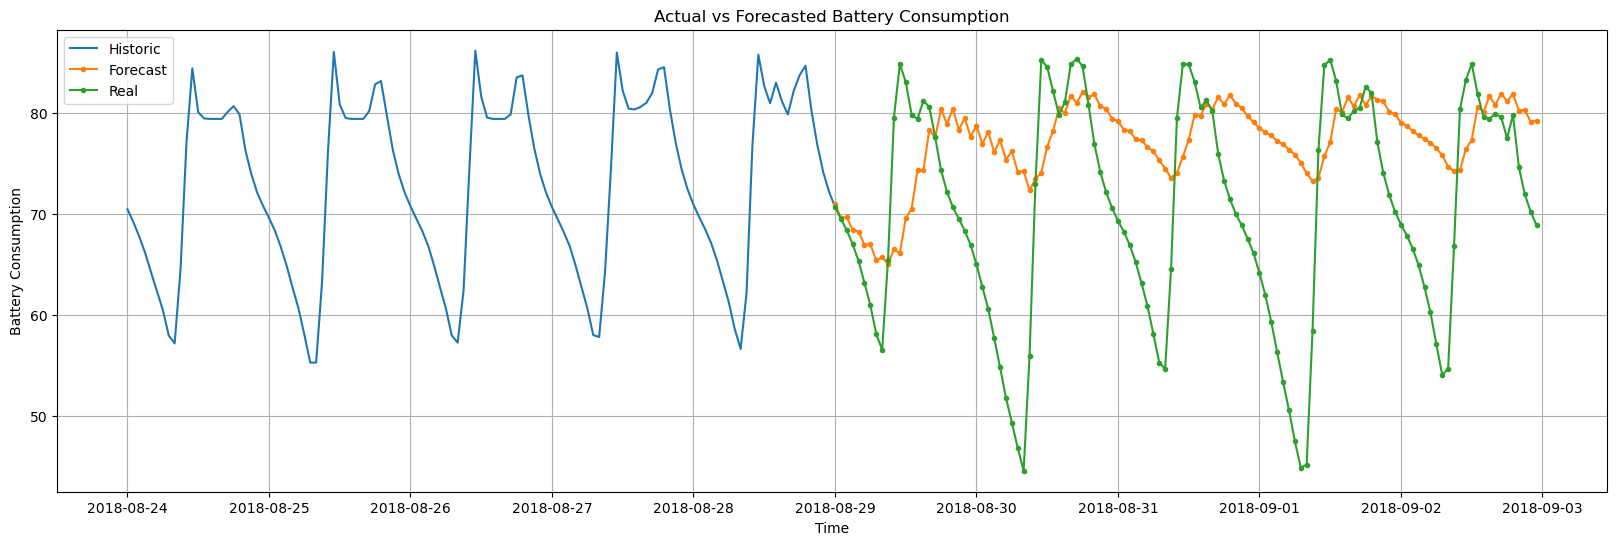

RMSE:  12.33511822165616
MSE:   152.15514154223382
MAE:   9.669601596408421


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [69]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble GRU

In [70]:
# Define model
gru_double_model = Sequential()
gru_double_model.add(GRU(units=50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_double_model.add(GRU(units=50))
gru_double_model.add(Dense(1, activation='sigmoid'))
gru_double_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_double_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 (None, 120, 50)           9000      
                                                                 
 gru_2 (GRU)                 (None, 50)                15300     
                                                                 
 dense_8 (Dense)             (None, 1)                 51        
                                                                 
Total params: 24,351
Trainable params: 24,351
Non-trainable params: 0
_________________________________________________________________


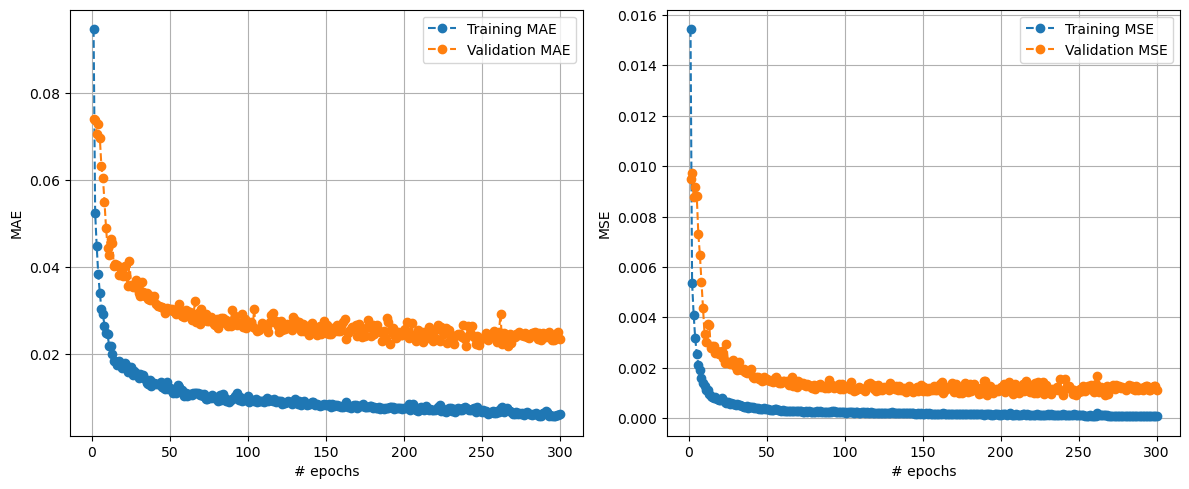

43/43 [==============================] - 1s 26ms/step - loss: 7.7988e-05 - mean_absolute_error: 0.0062 - val_loss: 0.0011 - val_mean_absolute_error: 0.0235


In [71]:
gru_double_model.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

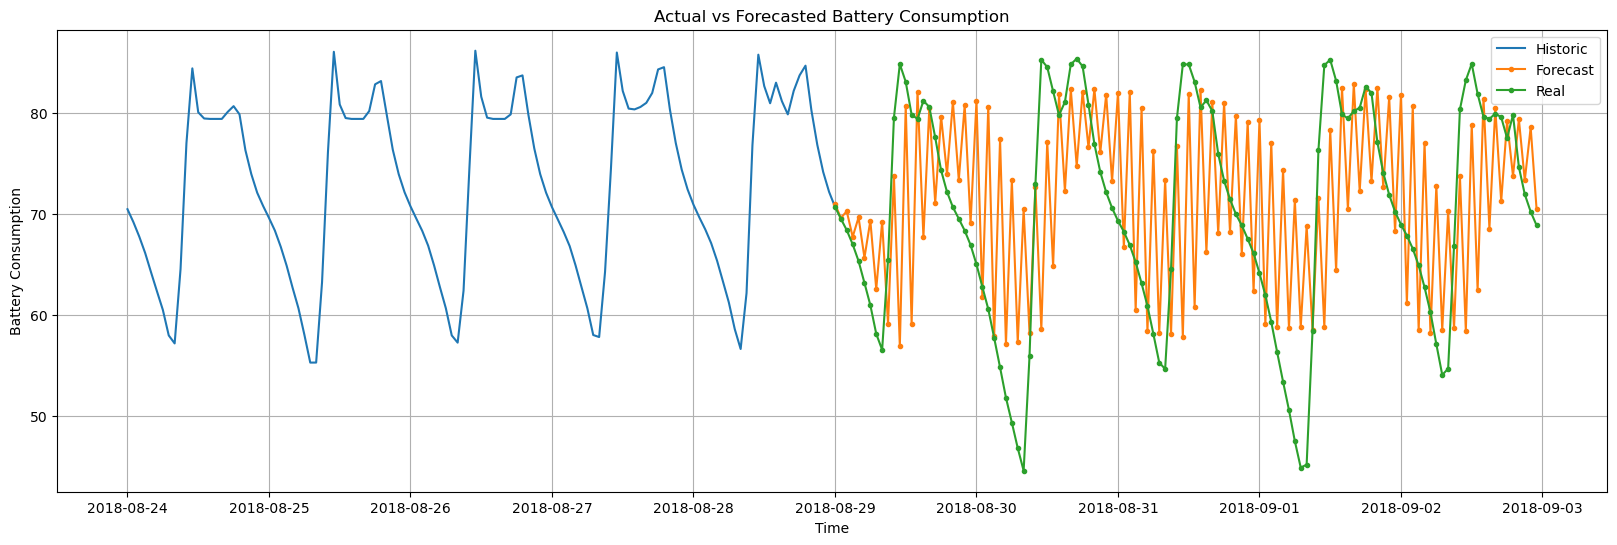

RMSE:  11.519355835176553
MSE:   132.6955588574161
MAE:   8.711965406629774


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [72]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

In [73]:
#compare_model_performance(test=test_dataset, seq_length=seq_length, future_steps=seq_length, models=[('gru_model', gru_model), ('gru_double_model', 
#                         gru_double_model)], scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU libro Jason

In [74]:
# Define model
gru_modelj = Sequential()
gru_modelj.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_modelj.add(Dense(n_nodes, activation='relu'))
gru_modelj.add(Dense(1, activation='sigmoid'))
gru_modelj.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_modelj.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_3 (GRU)                 (None, 50)                9000      
                                                                 
 dense_9 (Dense)             (None, 50)                2550      
                                                                 
 dense_10 (Dense)            (None, 1)                 51        
                                                                 
Total params: 11,601
Trainable params: 11,601
Non-trainable params: 0
_________________________________________________________________


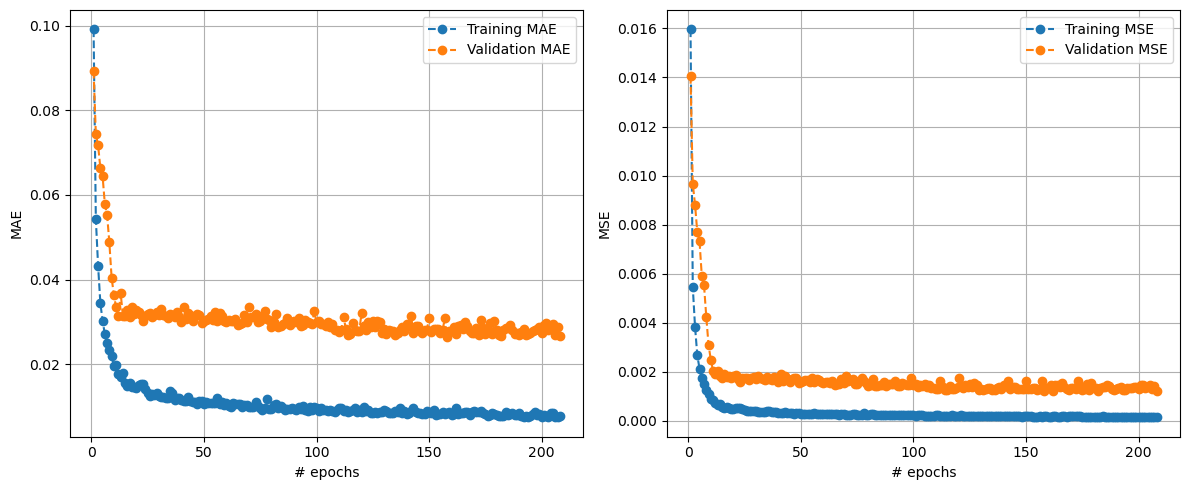

43/43 [==============================] - 1s 18ms/step - loss: 1.4739e-04 - mean_absolute_error: 0.0079 - val_loss: 0.0012 - val_mean_absolute_error: 0.0267


In [75]:
gru_modelj.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

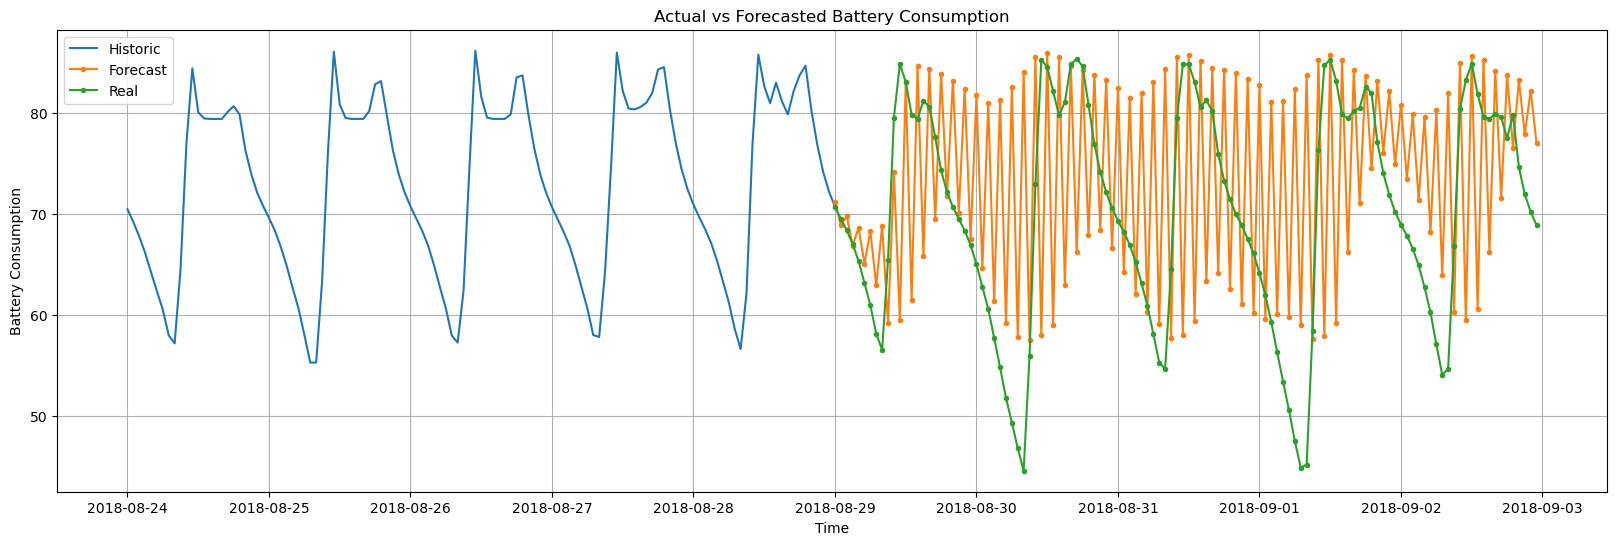

RMSE:  14.199199390780283
MSE:   201.61726333913515
MAE:   10.823687320285371


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [76]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_modelj, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU Sofisticado

In [77]:
# Crear el modelo
gru_models = Sequential()
# Capa GRU 1 (con 50 unidades)
gru_models.add(GRU(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa GRU 2 (con 50 unidades)
gru_models.add(GRU(50))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
gru_models.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
gru_models.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
gru_models.add(Dense(1))
gru_models.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
gru_models.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_4 (GRU)                 (None, 120, 50)           9000      
                                                                 
 dropout_2 (Dropout)         (None, 120, 50)           0         
                                                                 
 gru_5 (GRU)                 (None, 50)                15300     
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_11 (Dense)            (None, 64)                3264      
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 1)                

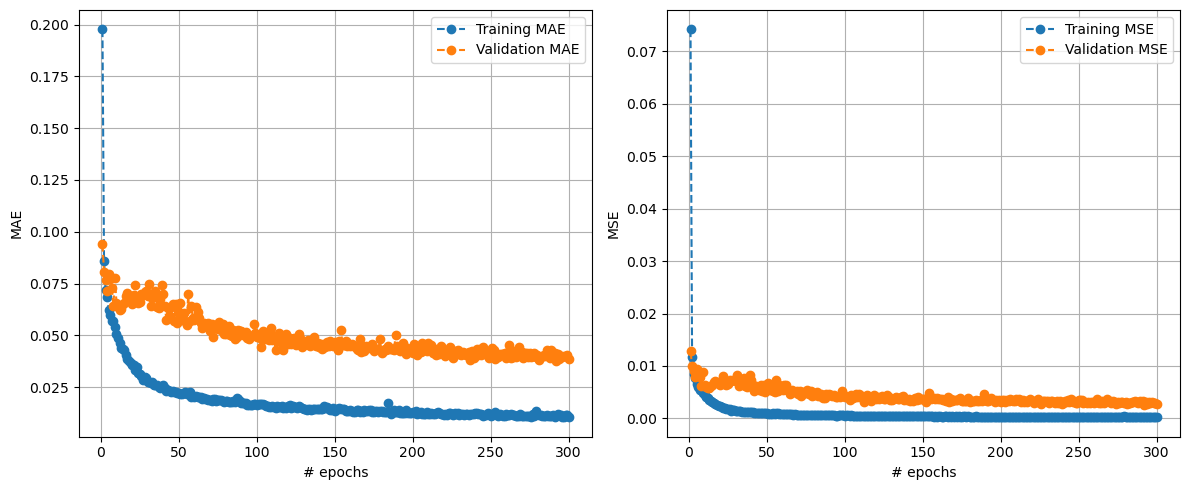

43/43 [==============================] - 1s 27ms/step - loss: 2.4561e-04 - mean_absolute_error: 0.0107 - val_loss: 0.0028 - val_mean_absolute_error: 0.0386


In [78]:
gru_models.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

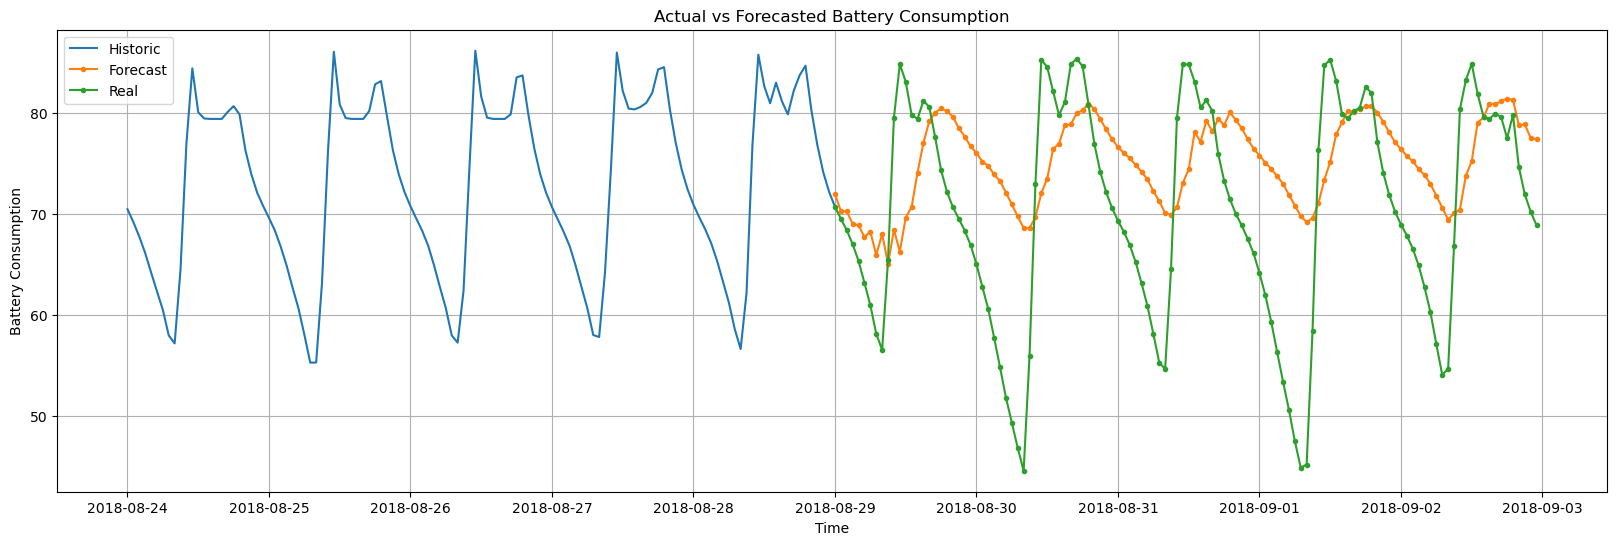

RMSE:  10.50064739776576
MSE:   110.26359577220485
MAE:   8.592294993930393


(                  fecha  temperature  pressure  battery  air_humidity  \
 0   2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1   2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2   2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3   2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4   2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                  ...          ...       ...      ...           ...   
 116 2018-08-28 20:00:00      27.4625  985.5325  80.3000       73.3425   
 117 2018-08-28 21:00:00      25.3925  986.2025  76.8750       75.4800   
 118 2018-08-28 22:00:00      24.2725  986.6025  74.1800       76.6000   
 119 2018-08-28 23:00:00      24.5425  986.9575  72.2075       77.9600   
 120 2018-08-29 00:00:00      23.8275  986.6275  70.7350       79.3800   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0        1.2050          0.0        807.0     0  
 1      

In [79]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_models, scaler_x=scaler_x, scaler_y=scaler_y)